In [ ]:
pip install yfinance

In [1]:
from tuning.grid_search_tuner import GridSearchTuner
from strategies.strategy_logic import rsi_strategy, macd_strategy
from utils.report_generator import ReportGenerator

In [2]:
param_grid = {"window": [10, 14, 20, 30], "entry": [25, 30], "exit": [70, 75]}
tuner = GridSearchTuner(
    symbols=["AAPL", "MSFT"],
    start_date="2020-01-01",
    end_date="2023-01-01",
    param_grid=param_grid,
    strategy_fn=rsi_strategy
)
tuner.run()

==== Top Configurations Across All Symbols ====
   window  entry  exit Symbol  Total Return [%]  Sharpe Ratio  \
0      30     25    70   AAPL        -70.545767      0.602595   
1      14     25    70   AAPL        -66.995211      0.488902   
2      14     30    70   AAPL        -75.988127      0.357874   
3      20     30    70   AAPL        -75.486268      0.279327   
4      20     25    70   AAPL        -75.164367      0.271873   
5      14     30    75   MSFT         77.996304      0.853413   
6      14     30    70   MSFT         42.657011      0.600542   
7      10     25    75   MSFT         34.937609      0.547285   
8      10     30    75   MSFT         30.001229      0.506699   
9      30     25    70   MSFT        -31.982865      0.471708   

   Max Drawdown [%]  
0        137.266004  
1         97.574760  
2         97.574760  
3         96.247823  
4         96.187289  
5         34.341903  
6         43.730197  
7         34.917169  
8         34.917169  
9         92.328

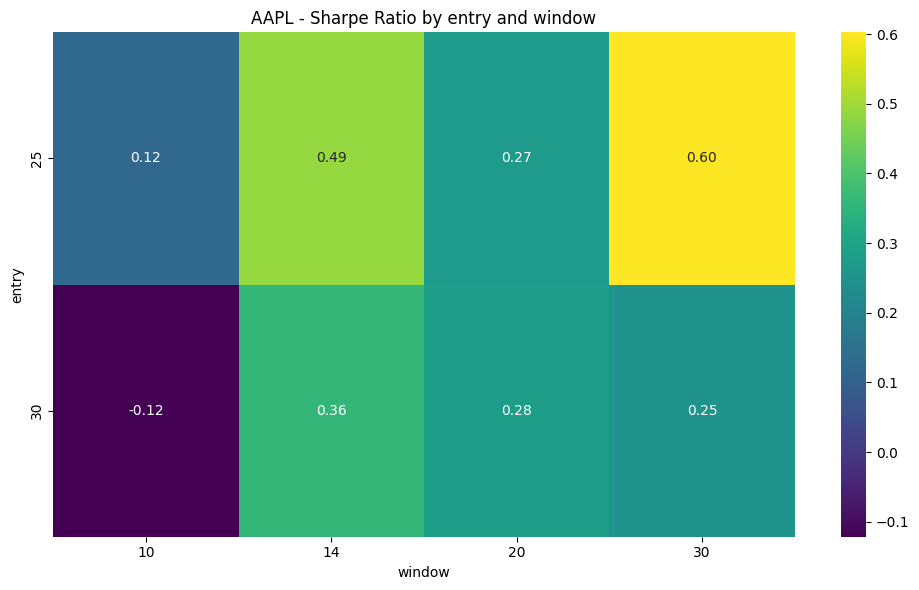

Exported all results to all_results_summary.csv


In [3]:
reporter = ReportGenerator(tuner.results)
reporter.summary()
reporter.plot_heatmap(symbol="AAPL", metric="Sharpe Ratio", index="entry", columns="window")
reporter.export_summary_csv()